In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

# Pruning

## Unstructured pruning of Conv2d with l1 (pruning_unstr_l1_con2d)
Первый эксперимент будет связан с unstructured pruning, это хорошая отправная точка. Для начала я буду использовать критерий l1 с разными порогами sparsity. Буду применять это только к Conv2d слоям модели. Для начала попробуем прунить как mask, так и phase слои. В данном эксперименте применялись конфиги:
- pruning_unstr_l1_0.1_con2d.yaml
- pruning_unstr_l1_0.2_con2d.yaml
- pruning_unstr_l1_0.3_con2d.yaml
- pruning_unstr_l1_0.4_con2d.yaml
- pruning_unstr_l1_0.5_con2d.yaml

Как можно понять из названия конфиги отличаются только параметрами sparsity. Ниже я построил графики зависимости метрик от параметра sparsity, где отразил как абсолютное изменение, так и относительное(в процентах)

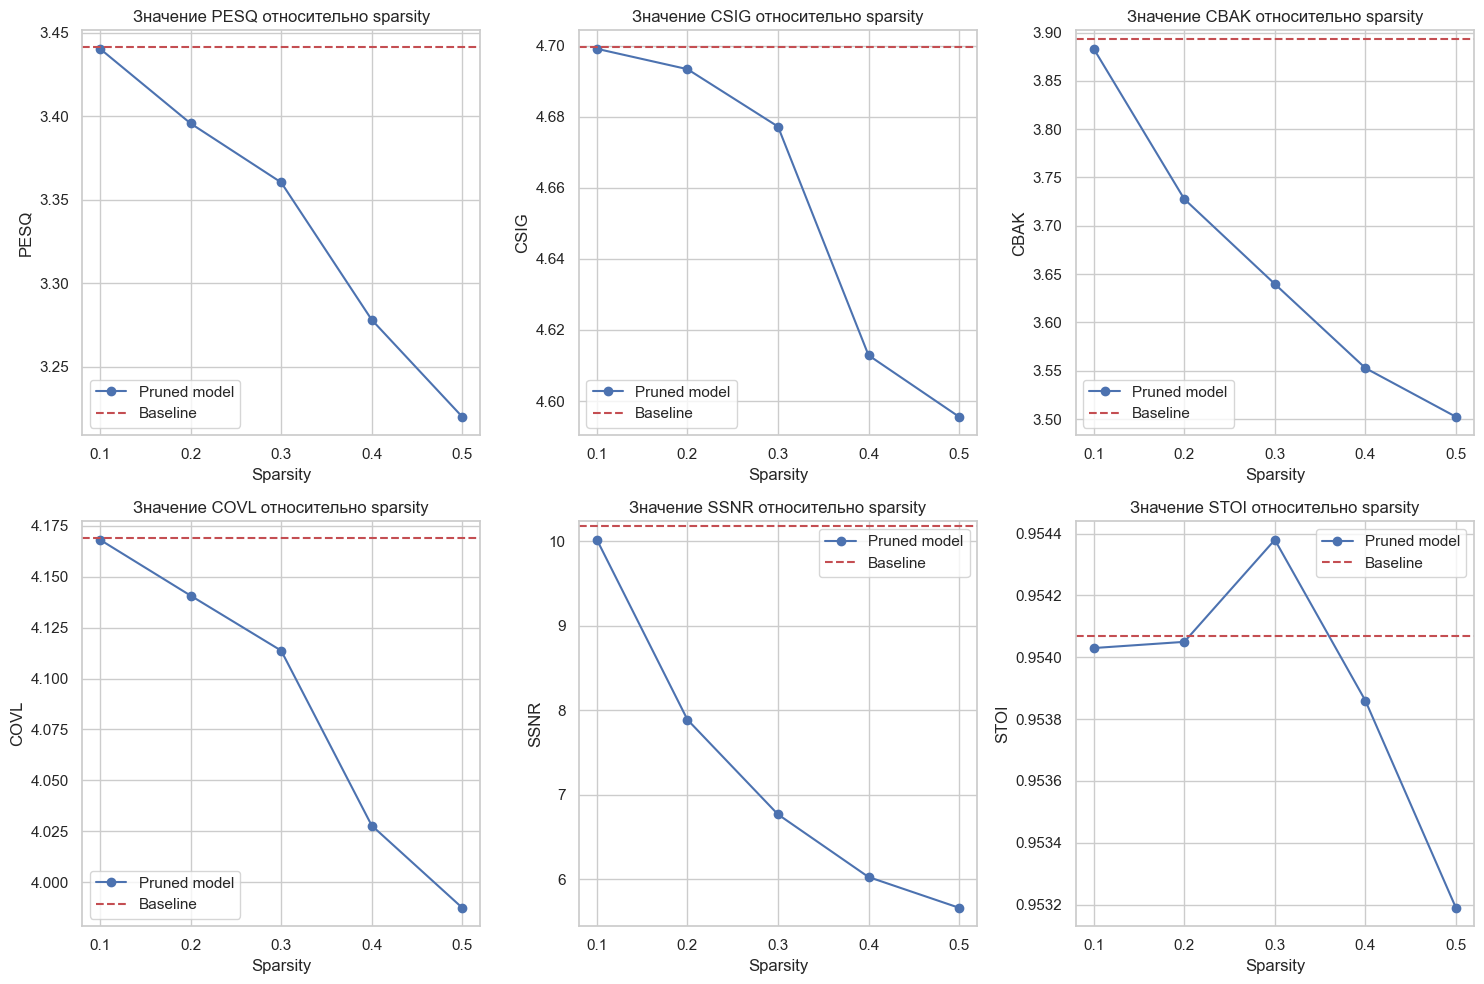

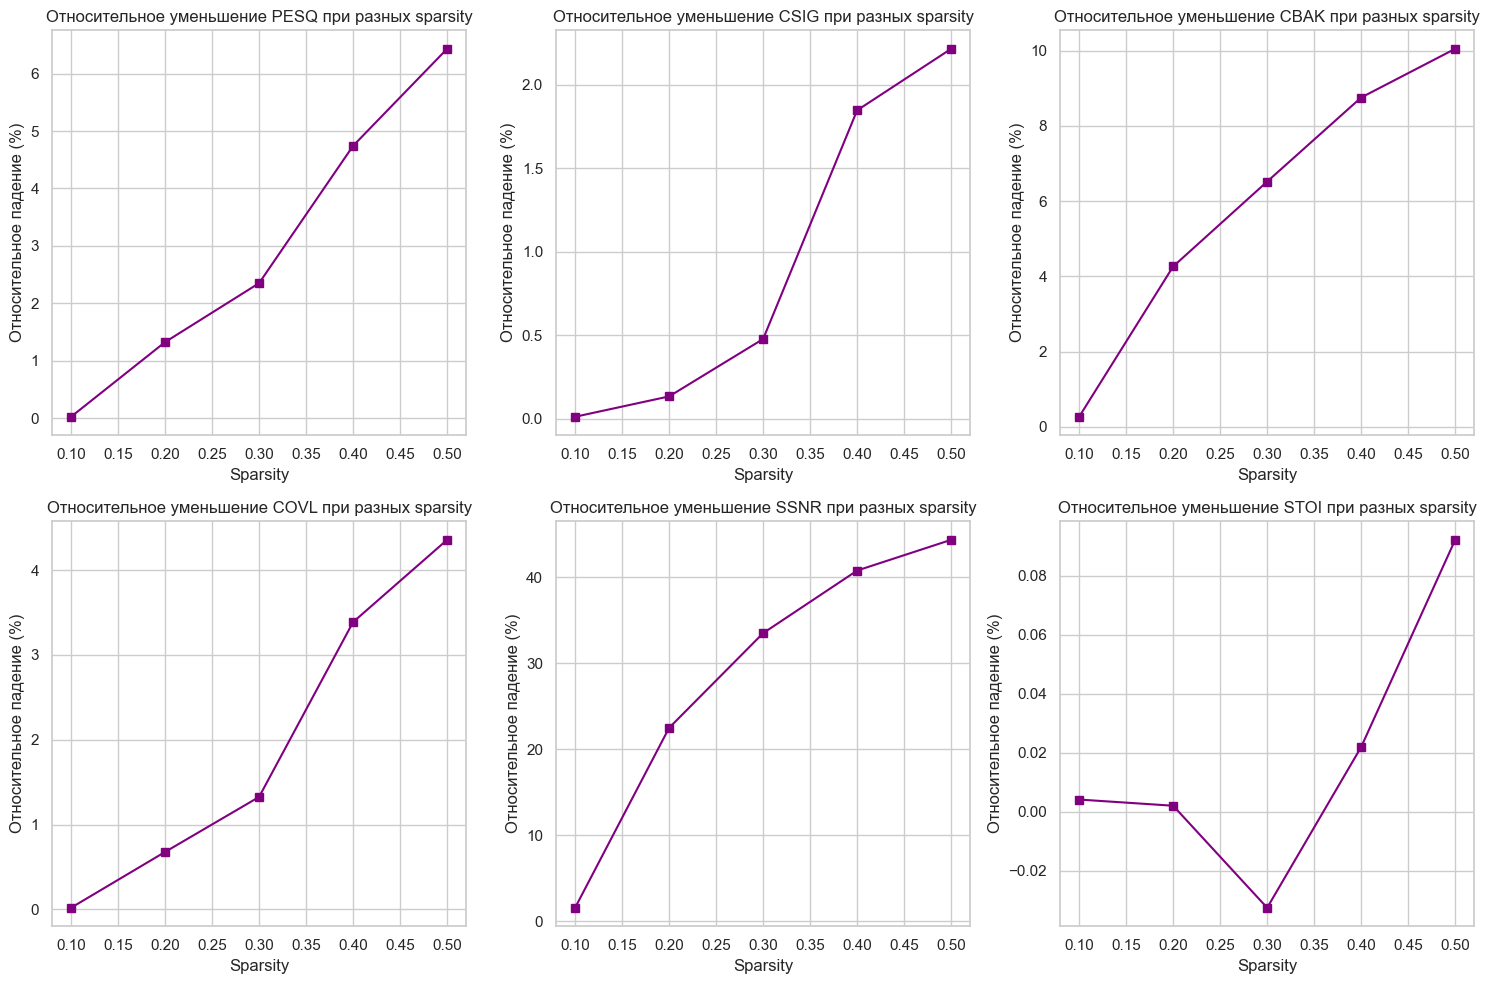

In [23]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Задаём имена столбцов в правильном порядке
column_names = [
    'timestamp', 'experiment_id', 'method', 'checkpoint',
    'params', 'flops', 'macs',
    'PESQ', 'CSIG', 'CBAK', 'COVL', 'SSNR', 'STOI'
]

# Читаем файл без заголовков
df = pd.read_csv('experiments/results.csv', header=None, names=column_names)

# Baseline (строка с method == 'none')
baseline = df[df['method'] == 'none'].iloc[0]

# Фильтруем pruning эксперименты
pattern = r'pruning_unstr_l1_([0-9.]+)_con2d'
pruning_rows = []

for idx, row in df.iterrows():
    match = re.search(pattern, row['experiment_id'])
    if match:
        if row['experiment_id'][-1] == 'd':
            sparsity = float(match.group(1))
            pruning_rows.append({**row.to_dict(), 'sparsity': sparsity})

pruning_df = pd.DataFrame(pruning_rows).sort_values('sparsity')

metrics = ['PESQ', 'CSIG', 'CBAK', 'COVL', 'SSNR', 'STOI']

# Строим графики (используйте тот же код, что и ранее)

# Создаём фигуру с двумя подграфиками: абсолютные значения и относительное изменение
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    # Абсолютные значения
    ax.plot(pruning_df['sparsity'], pruning_df[metric], marker='o', label='Pruned model')
    ax.axhline(y=baseline[metric], color='r', linestyle='--', label='Baseline')
    ax.set_xlabel('Sparsity')
    ax.set_ylabel(metric)
    ax.set_title(f'Значение {metric} относительно sparsity')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('experiments/metrics_vs_sparsity_absolute.png', dpi=150)
plt.show()

# Относительное снижение (в процентах)
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 10))
axes2 = axes2.flatten()

for idx, metric in enumerate(metrics):
    ax = axes2[idx]
    baseline_val = baseline[metric]
    relative_drop = (baseline_val - pruning_df[metric]) / baseline_val * 100
    ax.plot(pruning_df['sparsity'], relative_drop, marker='s', color='purple')
    ax.set_xlabel('Sparsity')
    ax.set_ylabel('Относительное падение (%)')
    ax.set_title(f'Относительное уменьшение {metric} при разных sparsity')
    ax.grid(True)

plt.tight_layout()
plt.savefig('experiments/metrics_vs_sparsity_relative_drop.png', dpi=150)
plt.show()

Можем отметить два необычных результата:
1) на графике для STOI можно заметить, что при sparsity=0.3 значение метрики получилось выше, чем у baseline модели. Как это объяснить пока не понятно

2) очень большое падение метрики SSNR, особенно это заметно на графике относительной ошибки. Уже при sparsity=0.2 мы получаем ухудшение результата на более чем 20%

Все остальные графики выглядят довольно ожидаемо

## Unstructured pruning of Conv2d with l1, ignoring phase layers (pruning_unstr_l1_con2d_nophase)

Мне захотелось понять причину такого падения SSNR. Моя гипотеза была в том, что прунинг слоев, отвечающих за работу с фазовой составляющей, сильно влияет на ошибку. Запустим эксперименты с разными порогами sparsity, игнорируя эти слои, и сравним с результатами предыдущего эксперимента

In [13]:
!python run_experiment.py --config configs/pruning_unstr_l1_0.4_con2d_nophase.yaml
!python run_experiment.py --config configs/pruning_unstr_l1_0.5_con2d_nophase.yaml

Initializing experiment process
run_experiment.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(experiment_config['data']['checkpoint_file'], map

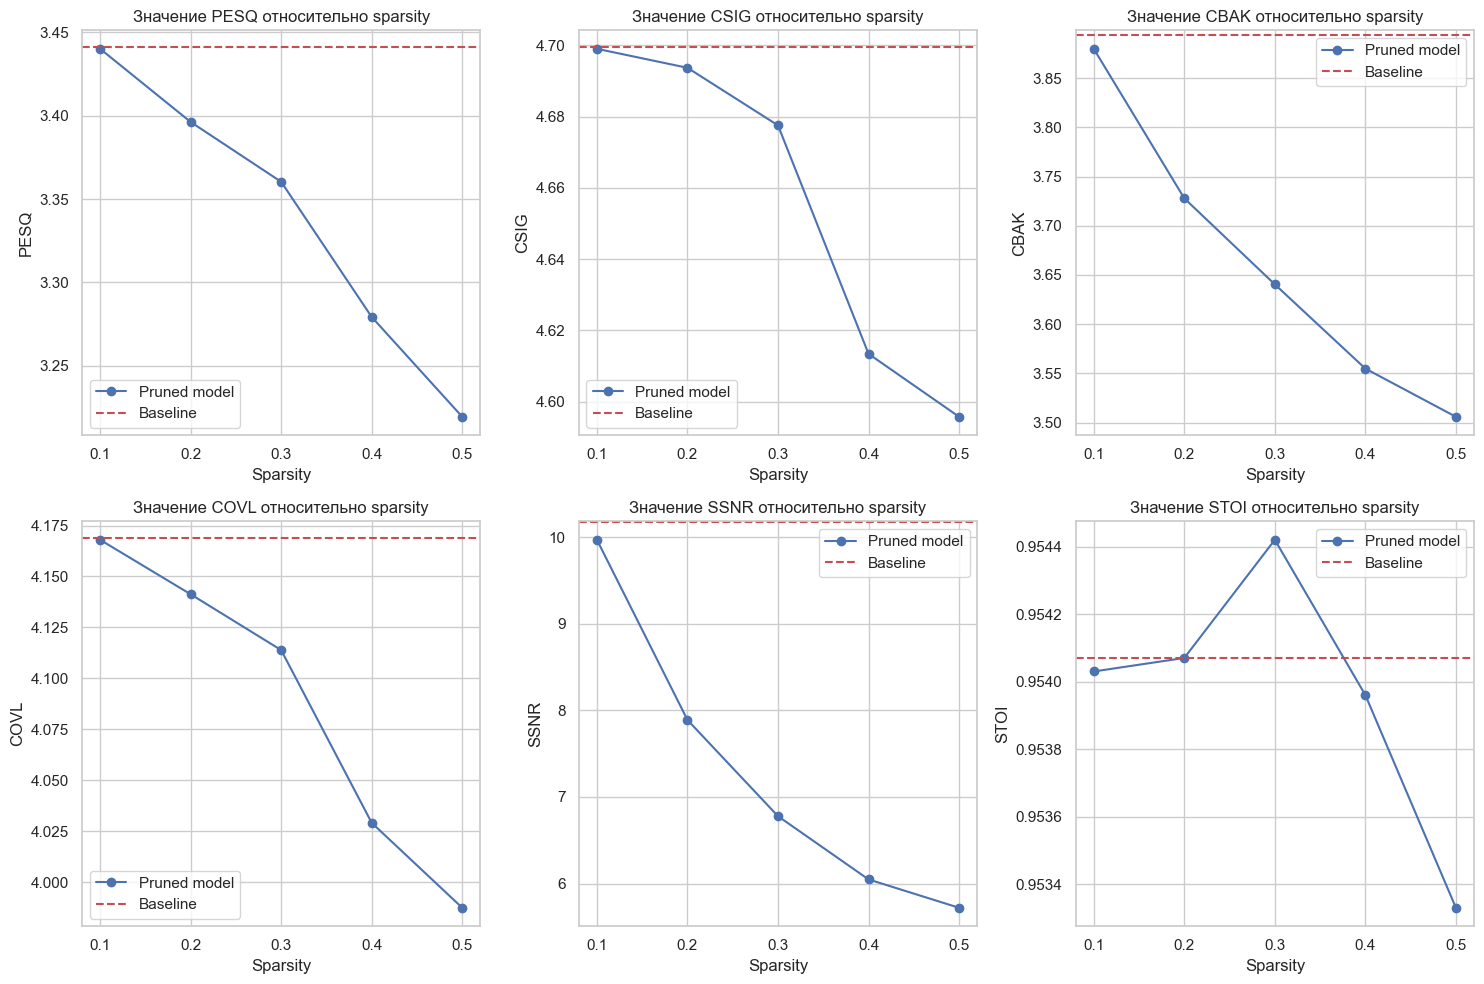

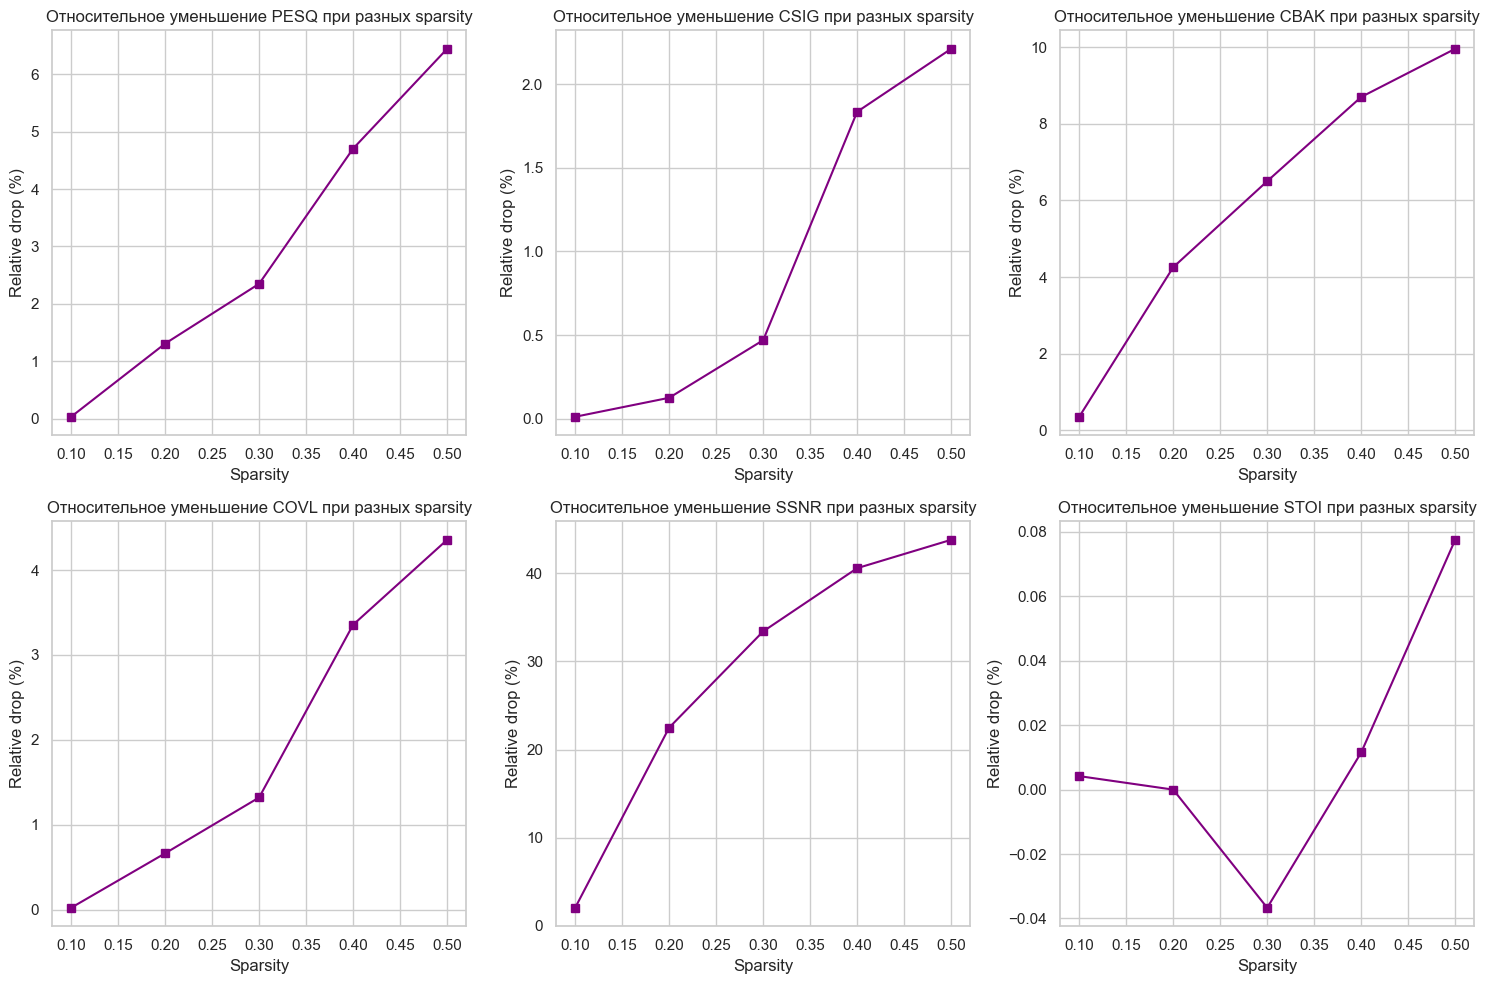

In [17]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline
# Задаём имена столбцов в правильном порядке
column_names = [
    'timestamp', 'experiment_id', 'method', 'checkpoint',
    'params', 'flops', 'macs',
    'PESQ', 'CSIG', 'CBAK', 'COVL', 'SSNR', 'STOI'
]

# Читаем файл без заголовков
df = pd.read_csv('experiments/results.csv', header=None, names=column_names)

# Baseline (строка с method == 'none')
baseline = df[df['method'] == 'none'].iloc[0]

# Фильтруем pruning эксперименты
pattern = r'pruning_unstr_l1_([0-9.]+)_con2d_nophase$'
pruning_rows = []
for idx, row in df.iterrows():
    match = re.search(pattern, row['experiment_id'])
    if match:
        sparsity = float(match.group(1))
        pruning_rows.append({**row.to_dict(), 'sparsity': sparsity})

pruning_df = pd.DataFrame(pruning_rows).sort_values('sparsity')

metrics = ['PESQ', 'CSIG', 'CBAK', 'COVL', 'SSNR', 'STOI']

# Строим графики (используйте тот же код, что и ранее)

# Создаём фигуру с двумя подграфиками: абсолютные значения и относительное изменение
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    # Абсолютные значения
    ax.plot(pruning_df['sparsity'], pruning_df[metric], marker='o', label='Pruned model')
    ax.axhline(y=baseline[metric], color='r', linestyle='--', label='Baseline')
    ax.set_xlabel('Sparsity')
    ax.set_ylabel(metric)
    ax.set_title(f'Значение {metric} относительно sparsity')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('experiments/metrics_vs_sparsity_absolute.png', dpi=150)
plt.show()

# Относительное снижение (в процентах)
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 10))
axes2 = axes2.flatten()

for idx, metric in enumerate(metrics):
    ax = axes2[idx]
    baseline_val = baseline[metric]
    relative_drop = (baseline_val - pruning_df[metric]) / baseline_val * 100
    ax.plot(pruning_df['sparsity'], relative_drop, marker='s', color='purple')
    ax.set_xlabel('Sparsity')
    ax.set_ylabel('Relative drop (%)')
    ax.set_title(f'Относительное уменьшение {metric} при разных sparsity')
    ax.grid(True)

plt.tight_layout()
plt.savefig('experiments/metrics_vs_sparsity_relative_drop.png', dpi=150)
plt.show()

Мы видим практически идентичные графики. Значит дело не в фазовых блоках. Значит дело в самой метрике SSNR, которая является намного более инженерной, чем к примеру PESQ. 

## Unstructured pruning of Conv2d with l1 and finetuning (kaggle_pruning_unstr_finetuning)

Чтобы разобраться с таким падением SSNR попробуем произвести fine tuning нашей модели после прунинга. Применим к модели unstructured pruning с критерием l1 и разными порогами sparsity. В качестве гиперпараметров finetuning-a будем использовать

epochs: 5 \
lr: 0.00001 \
num_files: 1000 \
batch_size: 2

Learning rate выбран низким специально, ведь нам нужно всего немного поменять веса чтобы скорректировать точность. Batch size равен 2 из соображений быстрой работы на моем устройстве

In [18]:
!python run_experiment.py --config configs/pruning_unstr_l1_0.2_con2d_finetune.yaml
!python run_experiment.py --config configs/pruning_unstr_l1_0.3_con2d_finetune.yaml
!python run_experiment.py --config configs/pruning_unstr_l1_0.4_con2d_finetune.yaml

Initializing experiment process
run_experiment.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(experiment_config['data']['checkpoint_file'], map

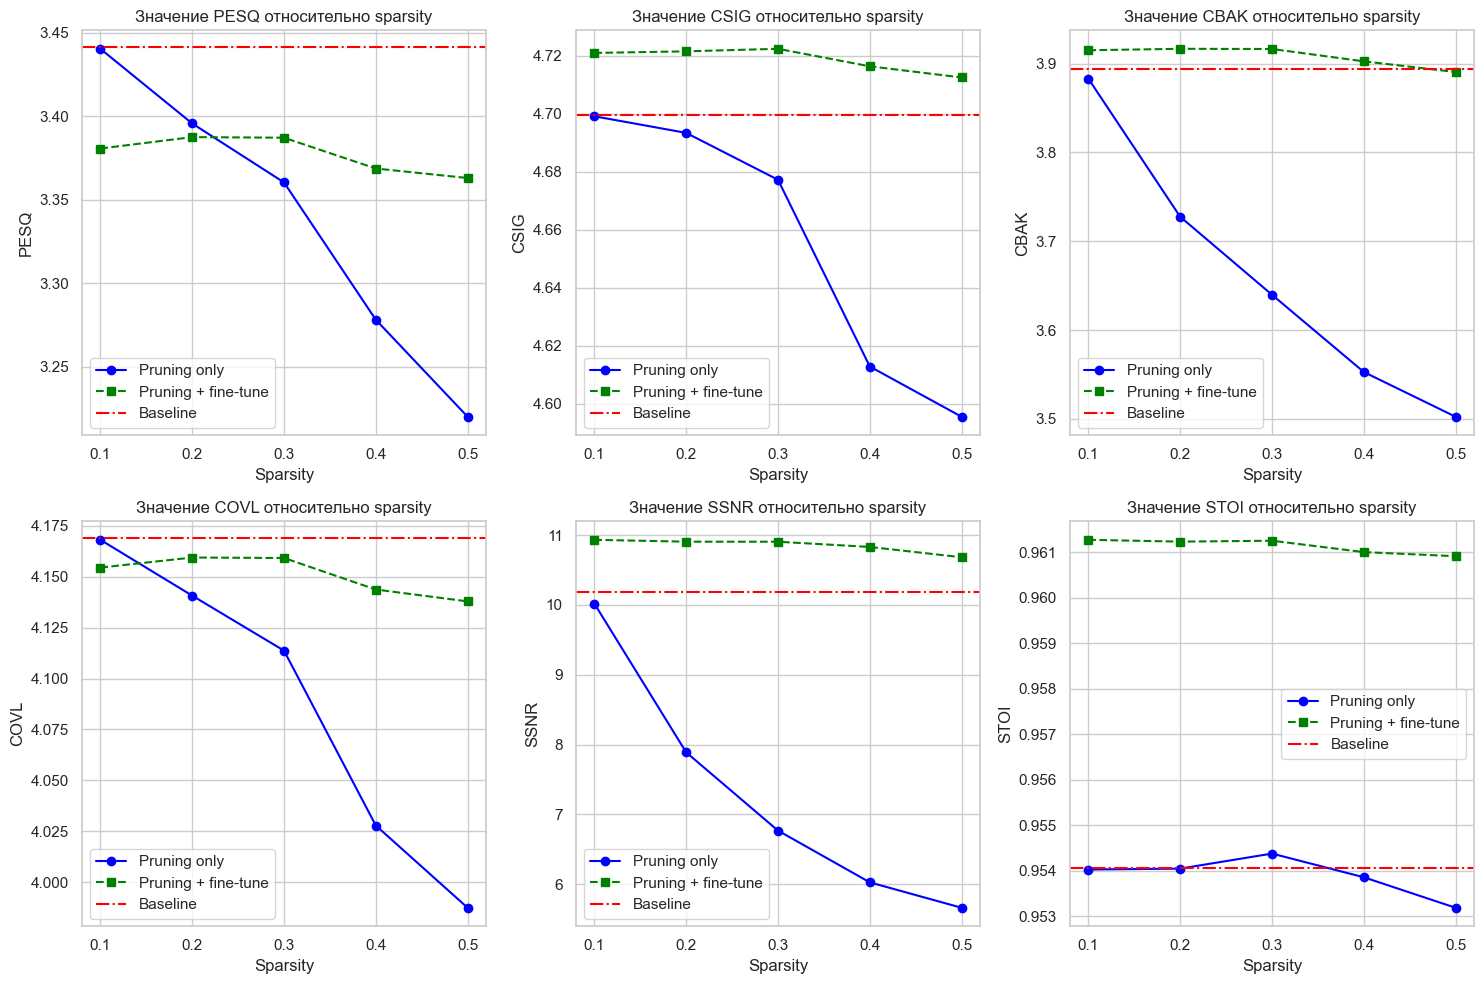

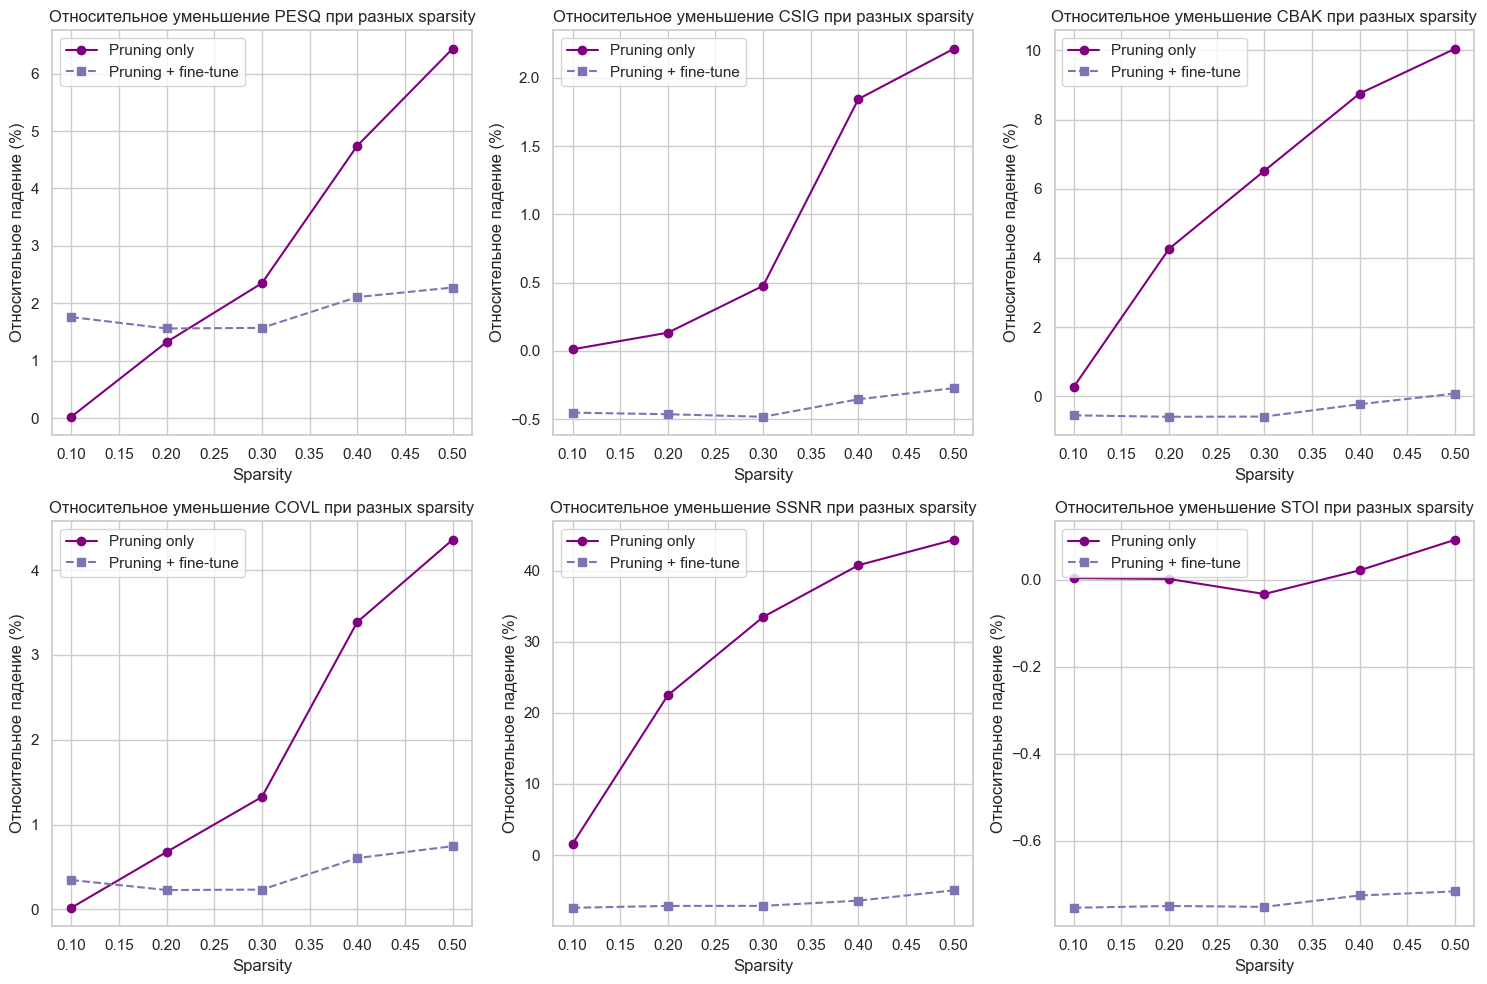

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Задаём имена столбцов (у вас файл без заголовка)
column_names = [
    'timestamp', 'experiment_id', 'method', 'checkpoint',
    'params', 'flops', 'macs',
    'PESQ', 'CSIG', 'CBAK', 'COVL', 'SSNR', 'STOI'
]

df = pd.read_csv('experiments/results.csv', header=None, names=column_names)

# Baseline (одна строка с method == 'none')
baseline = df[df['method'] == 'none'].iloc[0]

# --- 1. Извлекаем обычные pruning (без fine-tuning) ---
pattern_plain = r'pruning_unstr_l1_([0-9.]+)_con2d$'   # заканчивается на _con2d
plain_rows = []
for idx, row in df.iterrows():
    match = re.search(pattern_plain, row['experiment_id'])
    if match:
        sparsity = float(match.group(1))
        plain_rows.append({**row.to_dict(), 'sparsity': sparsity})
plain_df = pd.DataFrame(plain_rows).sort_values('sparsity')

# --- 2. Извлекаем pruning с fine-tuning ---
pattern_ft = r'pruning_unstr_l1_([0-9.]+)_con2d_finetune'
ft_rows = []
for idx, row in df.iterrows():
    match = re.search(pattern_ft, row['experiment_id'])
    if match:
        sparsity = float(match.group(1))
        ft_rows.append({**row.to_dict(), 'sparsity': sparsity})
ft_df = pd.DataFrame(ft_rows).sort_values('sparsity')

metrics = ['PESQ', 'CSIG', 'CBAK', 'COVL', 'SSNR', 'STOI']

# --- 3. Графики абсолютных значений (с двумя линиями) ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    # Обычный pruning (без fine-tuning)
    ax.plot(plain_df['sparsity'], plain_df[metric], marker='o', 
            color='blue', label='Pruning only')
    # Pruning + fine-tuning
    ax.plot(ft_df['sparsity'], ft_df[metric], marker='s', 
            color='green', linestyle='--', label='Pruning + fine-tune')
    # Baseline линия
    ax.axhline(y=baseline[metric], color='red', linestyle='-.', label='Baseline')
    ax.set_xlabel('Sparsity')
    ax.set_ylabel(metric)
    ax.set_title(f'Значение {metric} относительно sparsity')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('experiments/metrics_compare_absolute.png', dpi=150)
plt.show()

# --- 4. Графики относительного падения (в процентах) ---
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 10))
axes2 = axes2.flatten()

for idx, metric in enumerate(metrics):
    ax = axes2[idx]
    baseline_val = baseline[metric]
    # Относительное падение для обычного pruning
    drop_plain = (baseline_val - plain_df[metric]) / baseline_val * 100
    ax.plot(plain_df['sparsity'], drop_plain, marker='o', color='purple', label='Pruning only')
    # Относительное падение для pruning + fine-tune
    drop_ft = (baseline_val - ft_df[metric]) / baseline_val * 100
    ax.plot(ft_df['sparsity'], drop_ft, marker='s', color='m', linestyle='--', 
            label='Pruning + fine-tune')
    ax.set_xlabel('Sparsity')
    ax.set_ylabel('Относительное падение (%)')
    ax.set_title(f'Относительное уменьшение {metric} при разных sparsity')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('experiments/metrics_compare_relative_drop.png', dpi=150)
plt.show()

Можем видеть очень интересные результаты. В первую очередь бросается в глаза значимое повышение качества относительно pruning only. Более того, мы можем видеть что на некоторых метриках модель после дообучения показывает результат лучше, чем baseline. Настолько резкое повышение качества кажется довольно странным, но, к примеру, можно вспомнить Lottery Ticket Hypothesis, которая описывает подобный эффект. L1-прунинг выделил группу наиболее важных весов, а fine tuning скорректировал их работу. Наиболее удивительным для меня стал тот факт, что для такого результата хватило всего 1000 аудиофайлов из датасета

## Unstructured pruning of Conv2d and Linear layers with l1

Все это время я применял pruning только к Conv2d слоям. Тепреь давайте попробуем применить и к Linear и MultiAttention слоям. Для этого запустим следующие эксперименты и построим графики сравнения прунинга отдельно Conv2d слоев и Conv2d+Linear

In [1]:
!python run_experiment.py --config configs/unstructured_pruning/pruning_unstr_l1_con2d+linear/pruning_unstr_l1_0.1_con2d+linear.yaml
!python run_experiment.py --config configs/unstructured_pruning/pruning_unstr_l1_con2d+linear/pruning_unstr_l1_0.2_con2d+linear.yaml
!python run_experiment.py --config configs/unstructured_pruning/pruning_unstr_l1_con2d+linear/pruning_unstr_l1_0.3_con2d+linear.yaml
!python run_experiment.py --config configs/unstructured_pruning/pruning_unstr_l1_con2d+linear/pruning_unstr_l1_0.4_con2d+linear.yaml
!python run_experiment.py --config configs/unstructured_pruning/pruning_unstr_l1_con2d+linear/pruning_unstr_l1_0.5_con2d+linear.yaml

Initializing experiment process
run_experiment.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(experiment_config['data']['checkpoint_file'], map

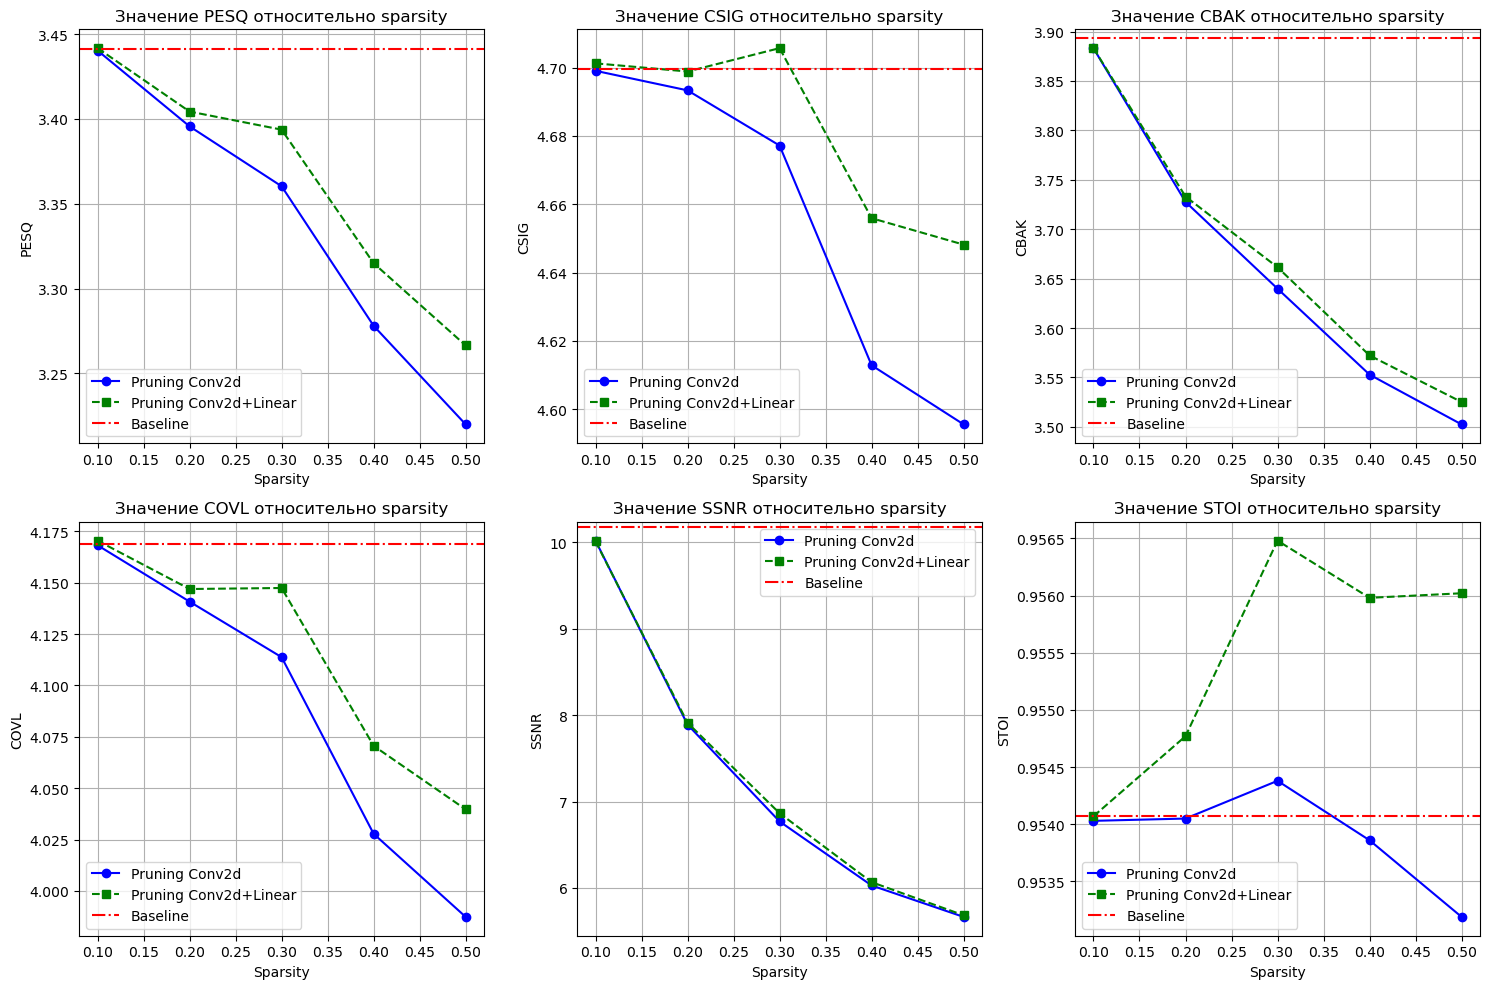

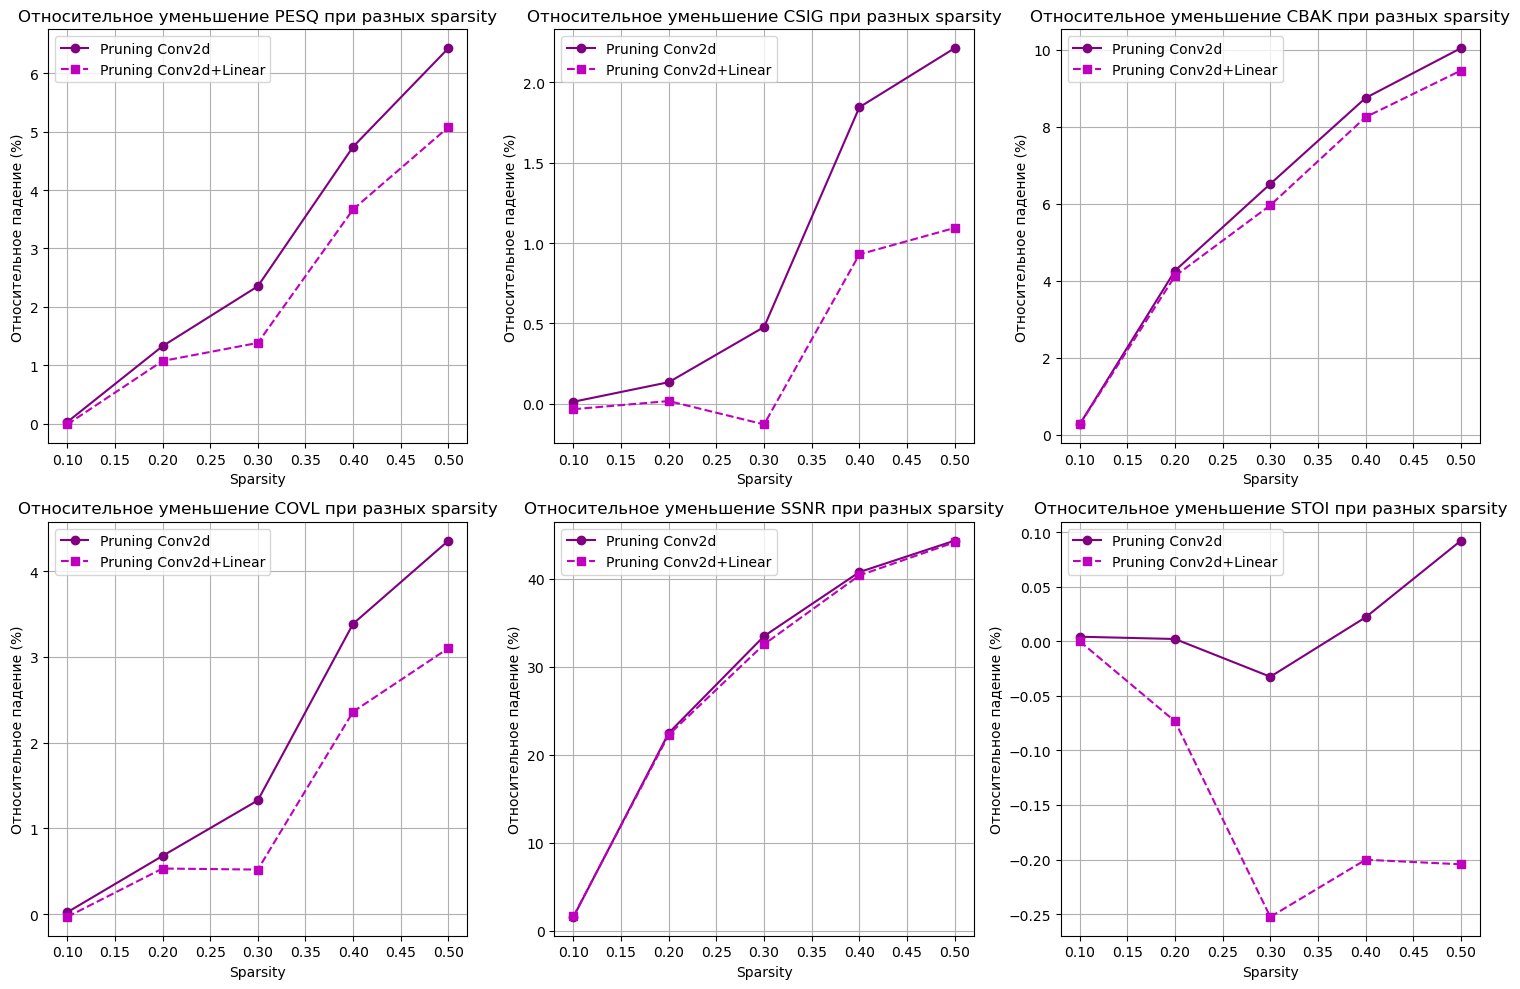

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

column_names = [
    'timestamp', 'experiment_id', 'method', 'checkpoint',
    'params', 'flops', 'macs',
    'PESQ', 'CSIG', 'CBAK', 'COVL', 'SSNR', 'STOI'
]

df = pd.read_csv('experiments/results.csv', header=None, names=column_names)
baseline = df[df['method'] == 'none'].iloc[0]
pattern_plain = r'pruning_unstr_l1_([0-9.]+)_con2d$'
plain_rows = []
for idx, row in df.iterrows():
    match = re.search(pattern_plain, row['experiment_id'])
    if match:
        sparsity = float(match.group(1))
        plain_rows.append({**row.to_dict(), 'sparsity': sparsity})
plain_df = pd.DataFrame(plain_rows).sort_values('sparsity')

# --- 2. Извлекаем pruning с fine-tuning ---
pattern_ft = r'pruning_unstr_l1_([0-9.]+)_con2d\+linear'
ft_rows = []
for idx, row in df.iterrows():
    match = re.search(pattern_ft, row['experiment_id'])
    if match:
        sparsity = float(match.group(1))
        ft_rows.append({**row.to_dict(), 'sparsity': sparsity})
ft_df = pd.DataFrame(ft_rows).sort_values('sparsity')

metrics = ['PESQ', 'CSIG', 'CBAK', 'COVL', 'SSNR', 'STOI']

# --- 3. Графики абсолютных значений (с двумя линиями) ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    # Обычный pruning (без fine-tuning)
    ax.plot(plain_df['sparsity'], plain_df[metric], marker='o', 
            color='blue', label='Pruning Conv2d')
    # Pruning + fine-tuning
    ax.plot(ft_df['sparsity'], ft_df[metric], marker='s', 
            color='green', linestyle='--', label='Pruning Conv2d+Linear')
    # Baseline линия
    ax.axhline(y=baseline[metric], color='red', linestyle='-.', label='Baseline')
    ax.set_xlabel('Sparsity')
    ax.set_ylabel(metric)
    ax.set_title(f'Значение {metric} относительно sparsity')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('experiments/metrics_compare_absolute_.png', dpi=150)
plt.show()

fig2, axes2 = plt.subplots(2, 3, figsize=(15, 10))
axes2 = axes2.flatten()

for idx, metric in enumerate(metrics):
    ax = axes2[idx]
    baseline_val = baseline[metric]
    drop_plain = (baseline_val - plain_df[metric]) / baseline_val * 100
    ax.plot(plain_df['sparsity'], drop_plain, marker='o', color='purple', label='Pruning Conv2d')
    drop_ft = (baseline_val - ft_df[metric]) / baseline_val * 100
    ax.plot(ft_df['sparsity'], drop_ft, marker='s', color='m', linestyle='--', 
            label='Pruning Conv2d+Linear')
    ax.set_xlabel('Sparsity')
    ax.set_ylabel('Относительное падение (%)')
    ax.set_title(f'Относительное уменьшение {metric} при разных sparsity')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('experiments/metrics_compare_relative_drop_.png', dpi=150)
plt.show()

Графики для метрик PESQ, CBAK, SSNR, COVL, CSIG выглядят достаточно похоже, в то время как график для STOI отличается довольно сильно. Можем отметить, что что прунинг Conv2d+Linear практически при любом значении sparsity был лучше по каждой метрике чем просто Conv2d. Думаю, что это можно интерпретировать так: когда мы применяем прунинг к Conv2d+Linear слоям, то sparsity распределяется равномернее. Также можно предположить, что в линейных слоях избыточности больше, чем в сверточных, из-за чего мы и получили такой результат. 

## Unstructured pruning of linear layers with l1

Проанализируем влияние каждого из типов слоев на результат прунинга. Ранее мы прунили отдельно Conv2d и Conv2d+Linear. Попробуем применить прунинг исключительно к линейным слоям

In [9]:
!python run_experiment.py --config configs/unstructured_pruning/pruning_unstr_l1_linear/pruning_unstr_l1_0.2_linear.yaml
!python run_experiment.py --config configs/unstructured_pruning/pruning_unstr_l1_linear/pruning_unstr_l1_0.3_linear.yaml
!python run_experiment.py --config configs/unstructured_pruning/pruning_unstr_l1_linear/pruning_unstr_l1_0.4_linear.yaml
!python run_experiment.py --config configs/unstructured_pruning/pruning_unstr_l1_linear/pruning_unstr_l1_0.5_linear.yaml

Initializing experiment process
run_experiment.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(experiment_config['data']['checkpoint_file'], map

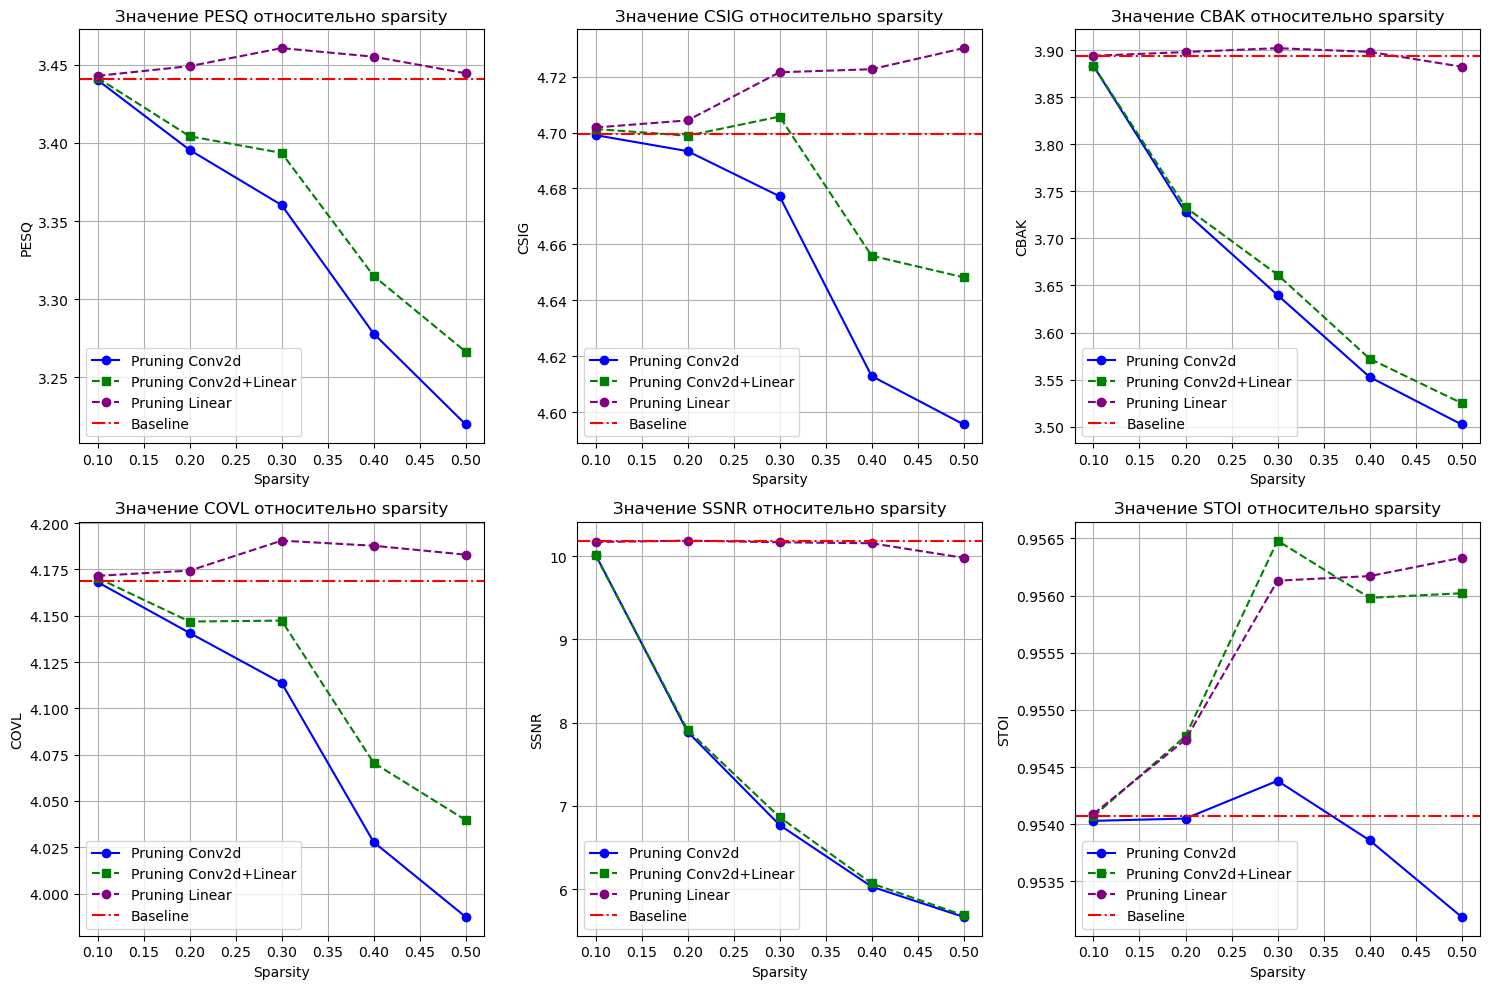

In [8]:
column_names = [
    'timestamp', 'experiment_id', 'method', 'checkpoint',
    'params', 'flops', 'macs',
    'PESQ', 'CSIG', 'CBAK', 'COVL', 'SSNR', 'STOI'
]

df = pd.read_csv('experiments/results.csv', header=None, names=column_names)
baseline = df[df['method'] == 'none'].iloc[0]
# Conv2d
pattern_plain = r'pruning_unstr_l1_([0-9.]+)_con2d$'
plain_rows = []
for idx, row in df.iterrows():
    match = re.search(pattern_plain, row['experiment_id'])
    if match:
        sparsity = float(match.group(1))
        plain_rows.append({**row.to_dict(), 'sparsity': sparsity})
plain_df = pd.DataFrame(plain_rows).sort_values('sparsity')

# Conv2d+linear
pattern_ft = r'pruning_unstr_l1_([0-9.]+)_con2d\+linear'
ft_rows = []
for idx, row in df.iterrows():
    match = re.search(pattern_ft, row['experiment_id'])
    if match:
        sparsity = float(match.group(1))
        ft_rows.append({**row.to_dict(), 'sparsity': sparsity})
ft_df = pd.DataFrame(ft_rows).sort_values('sparsity')

# Linear
linear_ft = r'pruning_unstr_l1_([0-9.]+)_linear'
lin_rows = []
for idx, row in df.iterrows():
    match = re.search(linear_ft, row['experiment_id'])
    if match:
        sparsity = float(match.group(1))
        lin_rows.append({**row.to_dict(), 'sparsity': sparsity})
lin_df = pd.DataFrame(lin_rows).sort_values('sparsity')

metrics = ['PESQ', 'CSIG', 'CBAK', 'COVL', 'SSNR', 'STOI']

# --- 3. Графики абсолютных значений (с двумя линиями) ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    # Conv2d
    ax.plot(plain_df['sparsity'], plain_df[metric], marker='o', 
            color='blue', label='Pruning Conv2d')
    # Conv2d+Linear
    ax.plot(ft_df['sparsity'], ft_df[metric], marker='s', 
            color='green', linestyle='--', label='Pruning Conv2d+Linear')
    # Linear
    ax.plot(lin_df['sparsity'], lin_df[metric], marker='o', 
            color='purple', linestyle='--', label='Pruning Linear')
    # Baseline линия
    ax.axhline(y=baseline[metric], color='red', linestyle='-.', label='Baseline')
    ax.set_xlabel('Sparsity')
    ax.set_ylabel(metric)
    ax.set_title(f'Значение {metric} относительно sparsity')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('experiments/metrics_compare_absolute_.png', dpi=150)
plt.show()


Можем видеть, что прунинг только линейных слоев почти не ухудшает, а то и улучшает результаты работы. Это связано с тем, что эти слои довольно малые. Не смотря на sparsity=0.5 реально нулевых весов в модели около 5%, что и дает подобный результат. 

# Quantization

## Dynamic Quantization

В качестве первого эксперимента попробуем запустить динамическое квантование линейных слоев. 

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Currently, qnnpack incorrectly ignores reduce_range")
!python run_experiment.py --config configs/quantization/quantization_dyn_int8.yaml

Initializing experiment process
run_experiment.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(experiment_config['data']['checkpoint_file'], map

Получили следующие результаты

WB-PESQ: 3.439, CSIG: 4.699, CBAK: 3.893, COVL: 4.167, SSNR: 10.182, STOI: 0.954

Params: 2.13 M, FLOPS:76.7 GFLOPS, MACS: 18.97 GMACs

Мы можем заметить, что у нас уменьшилось число параметров. Это похоже на какой то артефакт, ведь квантование не должно менять количество параметров, меняются только типы данных. Значит имеет смысл для экспериментов с квантизацией использовать отдельный подсчет веса итоговой модели вне зависимости от параметров. Реализуем это и запустим эксперимент еще раз

In [2]:
!python run_experiment.py --config configs/quantization/quantization_dyn_int8.yaml

Initializing experiment process
run_experiment.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(experiment_config['data']['checkpoint_file'], map

Мы получили следующий результат:

Base model size: 8.63 MB \
Quantized model size: 8.13 MB

Получаем размер на 0.5Мб меньше чем у бейзлайн модели. Модель уменьшилась в размере на 6%. Это говорит о том, что основное сжатие мы получим только при квантизации остальных слоев

## Static quantization

Цель - применить статическое пост‑тренировочное квантование модели до int8 для реального уменьшения размера и ускорения инференса(бэкенд qnnpack для Apple M1). В процессе возникли следующие проблемы: в стандартном Eager Mode статическое квантование падало с ошибками aten::add.out (отсутствие поддержки остаточных сложений в трансформерах) и aten::zero_ (несовместимость GRU с бэкендом), а также tuple has no attribute numel при попытке квантовать RNN. Мы перешли на FX Graph Mode (prepare_fx/convert_fx); заменили ручные сложения в TransformerBlock на FloatFunctional.add; создали кастомный QConfigMapping, исключив nn.GRU из статического квантования; после статической конвертации применили к GRU динамическое квантование.

In [ ]:
!python run_experiment.py --config configs/quantization/quantization_stat_int8.yaml

Модель сжата с 8.63 MB до 5.08 MB (в 1.7 раза). Можем заметить, что метрики упали довольно сильно. Попробуем применить fine tuning. А после этого попробуем еще сильнее сжать вес модели